# University of Engineering and Technology Peshawar, Nowshera Campus
Name: MUNSIFF ALI

Registration Number: 22JZELE0489
# Lab 6A: Linear Regression on Ohm's Law


**Topic:** Linear Regression using a synthetic Ohm's Law dataset  
**Dataset:** Current and voltage values for a 1 kOhm resistor

## Lab Objective
The objective of this lab is to model the relationship between current and voltage using linear regression. According to Ohm's Law, voltage is directly proportional to current, so the slope of the fitted line represents the estimated resistance.


## Method Summary
This notebook generates synthetic current values, calculates voltage from Ohm's Law, adds small random noise to imitate measurement error, fits a linear regression model, and evaluates the prediction error using MAE and RMSE.


## 1. Import Libraries and Generate Dataset
The following code imports the required libraries, defines the true resistance value, creates current readings, and generates noisy voltage measurements. The noise makes the synthetic data closer to real laboratory observations.


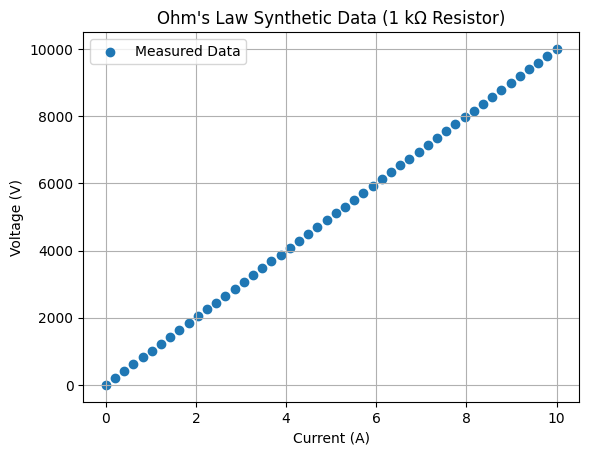

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set true resistance
R_true = 1000  # ohms

# Generate synthetic current (I) between 0 and 10 mA
I = np.linspace(0, 10, 50)  # Amperes

# Generate voltage using Ohm's Law: V = IR
V = R_true * I

# Add small measurement noise
noise = np.random.normal(0, 0.02, size=I.shape)
V_noisy = V + noise

I = I.reshape(-1, 1)

plt.scatter(I, V_noisy, label="Measured Data")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohm's Law Synthetic Data (1 kΩ Resistor)")
plt.grid(True)
plt.legend()
plt.show()

## 2. Prepare Test Data
This cell creates separate current values for testing and calculates their corresponding voltage values. Random noise is added so the test data also represents measured values rather than perfect theoretical values.


In [9]:
I_test = np.linspace(0, 0.02, 5)  # Amperes
I_test = I_test.reshape(-1, 1)

v_test= R_true * I_test
noise_test = np.random.normal(0, 0.02, size=I_test.shape)
v_test = v_test + noise_test

## 3. Train the Linear Regression Model
The model learns the best-fit line between current and voltage. For Ohm's Law, the learned slope is important because it estimates the resistance of the circuit.


In [10]:
# Fit Linear Regression
# model.fit() solves the linear regression equations using 
# matrix algebra (Normal Equation) to directly compute the optimal slope and intercept without using gradient descent.
model = LinearRegression()
model.fit(I, V_noisy)



LinearRegression()

## 4. Display Model Parameters
The slope and intercept are printed below. A slope close to 1000 indicates that the model has successfully learned the expected 1 kOhm resistance relationship.


In [11]:
print("slope, m",model.coef_ )  # slope (m)
print("intercept, b",model.intercept_ )   # intercept (b)

slope, m [1000.00133816]
intercept, b -0.003961739585065516


## 5. Predict Voltage for Test Current Values
The trained regression model is used to predict voltage values for the test current readings.


In [12]:
V_pred = model.predict(I_test)

## 6. Plot and Label the Results
The scatter plot shows measured test data, while the red line shows the regression prediction. A good fit should follow the measured points closely.


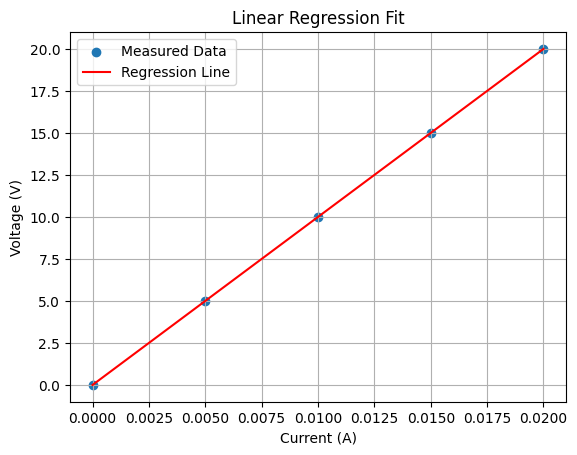

Estimated Resistance (slope): 1000.0013381635958
Intercept: -0.003961739585065516


In [13]:


plt.scatter(I_test, v_test, label="Measured Data")
plt.plot(I_test, V_pred, color="red", label="Regression Line")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Linear Regression Fit")
plt.grid(True)
plt.legend()
plt.show()

print("Estimated Resistance (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

## 7. Evaluate the Model
MAE and RMSE measure the average prediction error. Lower values mean the predicted voltage is close to the measured voltage.


In [14]:
# Compute metrics
MAE = mean_absolute_error(v_test, V_pred)
RMSE = np.sqrt(mean_squared_error(v_test, V_pred))

print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.011775741900098065
RMSE: 0.013570237116246345


## Conclusion
The linear regression model estimates the voltage-current relationship for a 1 kOhm resistor. Since Ohm's Law is linear, the regression line is suitable for this dataset, and the slope can be interpreted as the estimated resistance.
